# Transfer learning: Feature Extraction

Transfer learning is leveraging a working model's existing architecture and learning patterns for out own problem

## Downloading and becoming one with the data

In [17]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [3]:
# Download the data
#!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

In [5]:
# Get data (10% of food classes from Food101)\
import zipfile

# Unzip the downloaded file 
zip_ref = zipfile.ZipFile("10_food_classes_10_percent.zip")
zip_ref.extractall()
zip_ref.close()

In [11]:
# How many images in each folder?
import os

#Walk through data directory and list number of files
for dirpath, dirnames, filenames in os.walk("10_food_classes_10_percent"):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")

There are 2 directories and 0 images in 10_food_classes_10_percent
There are 10 directories and 0 images in 10_food_classes_10_percent/train
There are 0 directories and 75 images in 10_food_classes_10_percent/train/fried_rice
There are 0 directories and 75 images in 10_food_classes_10_percent/train/hamburger
There are 0 directories and 75 images in 10_food_classes_10_percent/train/chicken_curry
There are 0 directories and 75 images in 10_food_classes_10_percent/train/sushi
There are 0 directories and 75 images in 10_food_classes_10_percent/train/ramen
There are 0 directories and 75 images in 10_food_classes_10_percent/train/ice_cream
There are 0 directories and 75 images in 10_food_classes_10_percent/train/chicken_wings
There are 0 directories and 75 images in 10_food_classes_10_percent/train/steak
There are 0 directories and 75 images in 10_food_classes_10_percent/train/grilled_salmon
There are 0 directories and 75 images in 10_food_classes_10_percent/train/pizza
There are 10 director

### Create data loaders (preparing the data)

Use the ImageDataGenerator class to load in out images in batches

In [1]:
# Setup data inputs 
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 5

train_dir = "10_food_classes_10_percent/train/"
test_dir = "10_food_classes_10_percent/test/"

train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

print("Training data")
train_data_10_percent = train_datagen.flow_from_directory(train_dir,
                                                         target_size=IMAGE_SIZE,
                                                         batch_size=BATCH_SIZE,
                                                         class_mode="categorical")
print("Test data")
test_data = train_datagen.flow_from_directory(test_dir,
                                                         target_size=IMAGE_SIZE,
                                                         batch_size=BATCH_SIZE,
                                                         class_mode="categorical")

2026-04-05 17:55:33.820164: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Training data
Found 750 images belonging to 10 classes.
Test data
Found 2500 images belonging to 10 classes.


## Setting up callbacks (things that run whilst our model trains)

Callbacks are extra functionalities you can add to your models to be performed during or after training. Some of the most popular are:
* Tracking experiments with the Tensorboard callback
* Model checkpoint with the ModelCheckpoint callback
* Stopping a model from training(before it trains too long and overfits) with the EarlyStopping callback.

In [2]:
import datetime

def create_tensorboard_callback(dir_name, experiment_name):
    log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M")
    tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir)  # capital B
    print(f"Saving Tensorflow log files to: {log_dir}")
    return tensorboard_callback

## Creating models using Tensorflow Hub

In [3]:
import tensorflow_hub as hub
import tensorflow as tf
from tensorflow.keras import layers

/home/hacktheduck/Projects/tf_course/.venv/lib/python3.12/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [6]:
import tensorflow as tf
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.xception import preprocess_input as xception_preprocess
MODEL_REGISTRY = {
    "resnet_v2_101": tf.keras.applications.ResNet101V2,
    "xception": tf.keras.applications.Xception,
    "efficientnet": tf.keras.applications.EfficientNetB0,
}
PREPROCESSING_REGISTRY = {
    "resnet_v2_101": resnet_preprocess,
    "xception": xception_preprocess,
    "efficientnet": efficientnet_preprocess,
}
def create_model(model_name, num_classes=10, image_size=(224, 224)):
    if model_name not in MODEL_REGISTRY:
        raise ValueError(f"Unknown model '{model_name}'. Choose from: {list(MODEL_REGISTRY.keys())}")
    base_model = MODEL_REGISTRY[model_name](
        weights="imagenet",
        include_top=False,
        pooling="avg",
        input_shape=(*image_size, 3)
    )
    base_model.trainable = False
    preprocess = PREPROCESSING_REGISTRY[model_name]
    model = tf.keras.Sequential([
        layers.Input(shape=(*image_size, 3)),
        layers.Lambda(preprocess, name="preprocessing"),
        base_model,
        layers.Dense(num_classes, activation="softmax", name="output_layer")
    ])
    return model

In [8]:
# Create Resnet model
resnet_model = create_model("resnet_v2_101")
resnet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ preprocessing (Lambda)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet101v2 (Functional)        │ (None, 2048)           │    42,626,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,647,050 (162.69 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 42,626,560 (162.61 MB)

In [9]:
# Create Efficientnet model
efficientnet_model = create_model("efficientnet")
efficientnet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ preprocessing (Lambda)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [10]:
# Plot the validation and training curves separetly 
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random


def plot_loss_curves(history):
    """
    Returns separate loss curves and validation metrics.
    """
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]

    epochs = range(len(history.history["loss"])) 

    # Plot model loss 
    plt.plot(epochs, loss, label="training loss")
    plt.plot(epochs, val_loss, label="validation loss")
    plt.title("Loss")
    plt.xlabel("epochs")
    plt.legend()

    # Plot model accuracy 
    plt.figure()
    plt.plot(epochs, accuracy, label="training accuracy")
    plt.plot(epochs, val_accuracy, label="validation accuracy")
    plt.title("Accuracy")
    plt.xlabel("epochs")
    plt.legend()

In [11]:
# Compile resnet model
resnet_model.compile(loss="categorical_crossentropy",
                    optimizer="adam",
                    metrics=["accuracy"])

In [12]:
resnet_history = resnet_model.fit(
    train_data_10_percent,
    epochs=10,
    steps_per_epoch=len(train_data_10_percent),
    validation_data=test_data,
    callbacks=[create_tensorboard_callback(
        dir_name="tensorflow_hub",
        experiment_name="resnet_v2_50"
    )]
)

Saving Tensorflow log files to: tensorflow_hub/resnet_v2_50/20260405-1759
Epoch 1/10


2026-04-05 17:59:23.979703: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f6da8075c70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-05 17:59:23.979717: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-04-05 17:59:24.172588: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-05 17:59:25.668061: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
I0000 00:00:1775404775.970701    9191 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


24/24 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.1427 - loss: 2.3354 - val_accuracy: 0.1436 - val_loss: 2.2796
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 325ms/step - accuracy: 0.1507 - loss: 2.2577 - val_accuracy: 0.1856 - val_loss: 2.2488
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 329ms/step - accuracy: 0.2227 - loss: 2.2098 - val_accuracy: 0.1884 - val_loss: 2.2290
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 332ms/step - accuracy: 0.2267 - loss: 2.1752 - val_accuracy: 0.1928 - val_loss: 2.2196
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 331ms/step - accuracy: 0.2453 - loss: 2.1422 - val_accuracy: 0.1892 - val_loss: 2.2124
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 346ms/step - accuracy: 0.2493 - loss: 2.1337 - val_accuracy: 0.1796 - val_loss: 2.2091
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 344ms/step - accuracy: 0.2827 - loss: 2.0956 - val_accuracy: 0.1956 - val_loss: 2.2013
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 341ms/step - accuracy: 0.3133 - loss: 2.0730 - val_accuracy: 0.1920 - val_lo

In [13]:
# Compile efficientnet model
efficientnet_model.compile(loss="categorical_crossentropy",
                    optimizer="adam",
                    metrics=["accuracy"])

In [14]:
efficientnet_history = efficientnet_model.fit(
    train_data_10_percent,
    epochs=10,
    steps_per_epoch=len(train_data_10_percent),
    validation_data=test_data,
    callbacks=[create_tensorboard_callback(
        dir_name="tensorflow_hub",
        experiment_name="efficientnet"
    )]
)

Saving Tensorflow log files to: tensorflow_hub/efficientnet/20260405-1801
Epoch 1/10


2026-04-05 18:01:48.454343: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-05 18:01:48.571427: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-05 18:01:48.689871: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-05 18:01:48.807870: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-05 18:01:49.325843: E external/local_xla/xla/stream_

 9/24 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.0826 - loss: 2.3341

2026-04-05 18:01:58.587413: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-05 18:01:58.700660: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-05 18:01:59.145906: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-05 18:01:59.257234: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-05 18:01:59.705983: E external/local_xla/xla/stream_

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.0900 - loss: 2.3353

2026-04-05 18:02:13.636997: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-05 18:02:13.746002: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-05 18:02:13.854974: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-05 18:02:13.964611: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-05 18:02:14.074770: E external/local_xla/xla/stream_

24/24 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.0973 - loss: 2.3332 - val_accuracy: 0.1000 - val_loss: 2.3292
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - accuracy: 0.0893 - loss: 2.3444 - val_accuracy: 0.1000 - val_loss: 2.3125
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - accuracy: 0.0893 - loss: 2.3376 - val_accuracy: 0.1000 - val_loss: 2.3198
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step - accuracy: 0.0933 - loss: 2.3274 - val_accuracy: 0.1000 - val_loss: 2.3170
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step - accuracy: 0.0907 - loss: 2.3283 - val_accuracy: 0.0796 - val_loss: 2.3298
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.0920 - loss: 2.3337 - val_accuracy: 0.1000 - val_loss: 2.3213
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.0907 - loss: 2.3253 - val_accuracy: 0.1000 - val_loss: 2.3148
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 158ms/step - accuracy: 0.0853 - loss: 2.3223 - val_accuracy: 0.1000 - val_lo

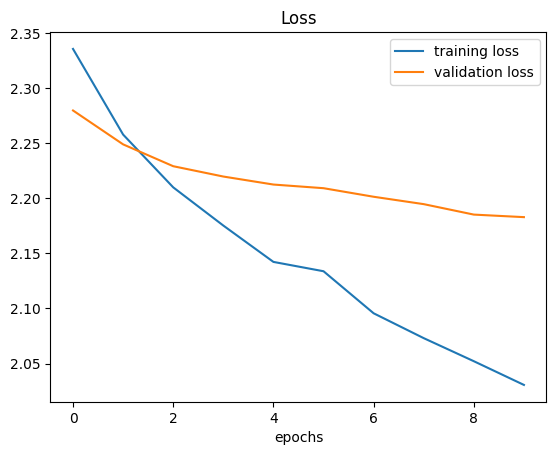

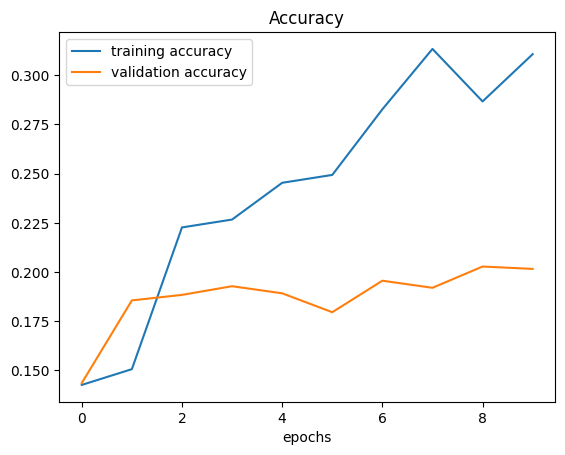

In [15]:
plot_loss_curves(resnet_history)

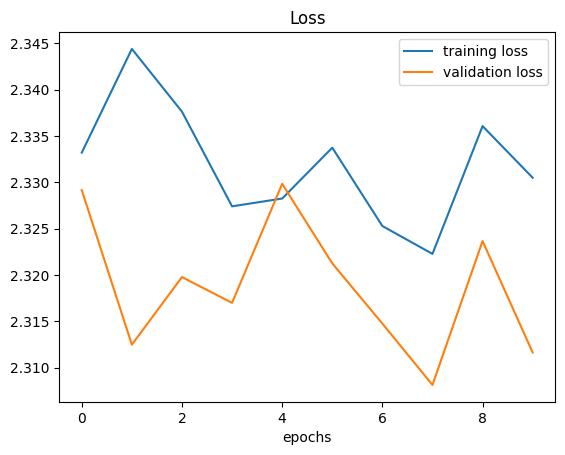

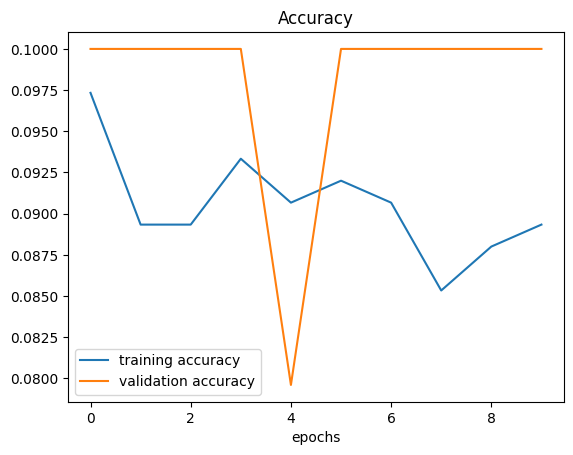

In [16]:
plot_loss_curves(efficientnet_history)

## Different types of transfer learning

* Using an existing model with no changes
* Using the prelearned patterns of an existing model (Feature extraction)
* Use the prelearned patterns of an existing model and "fine-tune" many or all of the underlying layers (fine-tuning)